<a href="https://colab.research.google.com/github/Zekaiiz/MSSP-6070-Zekai-Zhang/blob/main/ASSIGNMENT_3_Visualizing_a_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv('HousingPrices.csv', encoding='latin1')
df.head()

Saving HousingPrices.csv to HousingPrices (4).csv


,Id,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
0,1,65.0,8450.0,2Story,7,5,2003,856.0,Y,856,854,2,8,2,548,2008,208500
1,2,80.0,9600.0,1Story,6,8,1976,NaN,Y,1262,0,2,6,2,460,2007,181500
2,3,68.0,11250.0,2Story,7,5,2001,920.0,Y,920,866,2,6,2,608,2008,223500
3,4,60.0,9550.0,2Story,7,5,1915,NaN,Y,961,756,1,7,3,642,2006,140000
4,5,84.0,14260.0,2Story,8,5,2000,1145.0,Y,1145,1053,2,9,3,836,2008,250000


In [42]:
# 1. What is the mean and standard deviation of the price of housing?
mean_price = df["SalePrice"].mean()
median_price = df['SalePrice'].median()
std_price = df["SalePrice"].std()

print("Mean Price:", mean_price)
print("Standard Deviation of Price:", std_price)
print("Median Price:", median_price)

Mean Price: 180921.19589041095
Standard Deviation of Price: 79442.50288288663
Median Price: 163000.0


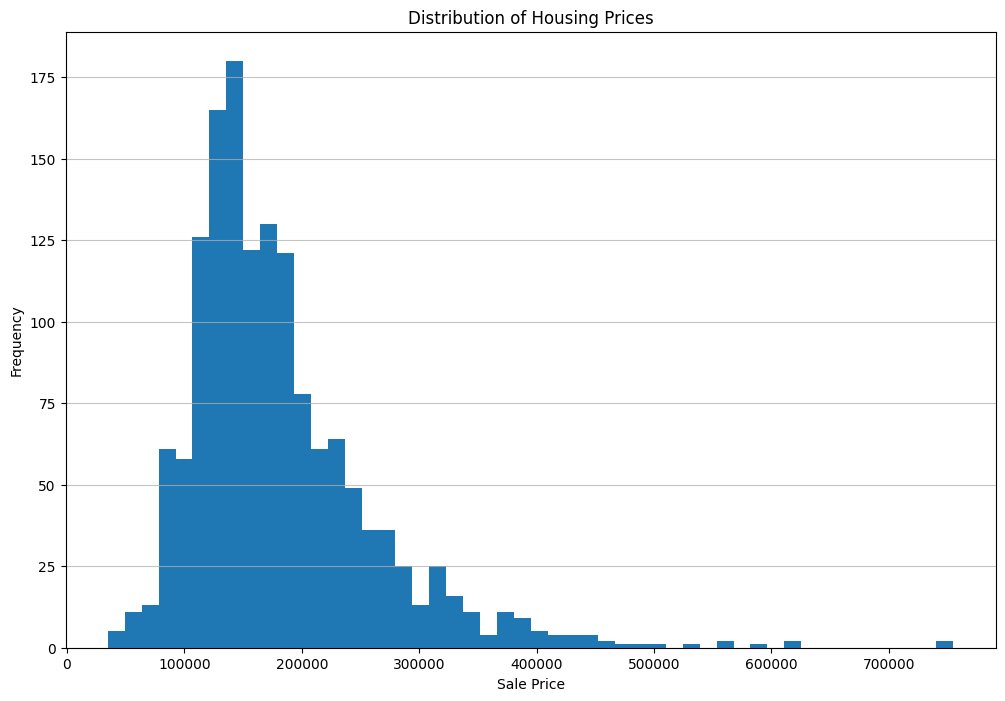

In [43]:
# 2.  Generate a histogram of the housing price.
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.hist(df["SalePrice"],bins=50)
plt.title("Distribution of Housing Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

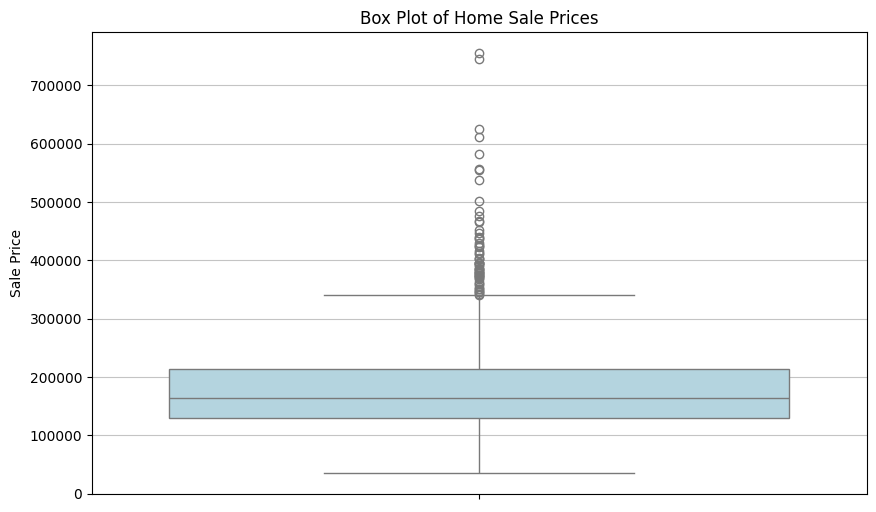

In [44]:
# 3.Are there any outliers that may impact the analysis?  How would you handle the outliers if identified?
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['SalePrice'], color='lightblue')
plt.ylabel('Sale Price')
plt.xlabel('')
plt.title('Box Plot of Home Sale Prices')
plt.grid(axis='y', alpha=0.75)

plt.show()

In [45]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df["SalePrice"] < lower_bound) | (df["SalePrice"] > upper_bound)]


print(f"Q1 (25th percentile): {Q1:,.2f}")
print(f"Q3 (75th percentile): {Q3:,.2f}")
print(f"IQR (Interquartile Range): {IQR:,.2f}")
print(f"Lower Bound for Outliers: {lower_bound:,.2f}")
print(f"Upper Bound for Outliers: {upper_bound:,.2f}")
print(f"Number of outliers in SalePrice: {len(outliers)}")



Q1 (25th percentile): 129,975.00
Q3 (75th percentile): 214,000.00
IQR (Interquartile Range): 84,025.00
Lower Bound for Outliers: 3,937.50
Upper Bound for Outliers: 340,037.50
Number of outliers in SalePrice: 61


In [46]:
#4. Model without ouliers
df_no_outliers = df[(df["SalePrice"] >= lower_bound) & (df["SalePrice"] <= upper_bound)]

print("Original dataset size:", len(df))
print("New dataset size after removing outliers:", len(df_no_outliers))

new_mean = df_no_outliers["SalePrice"].mean()
new_std = df_no_outliers["SalePrice"].std()

print(f"New Mean (after removing outliers): {new_mean:,.2f}")
print(f"New Std Dev (after removing outliers): {new_std:,.2f}")

Original dataset size: 1460
New dataset size after removing outliers: 1399
New Mean (after removing outliers): 170,237.13
New Std Dev (after removing outliers): 59,230.13


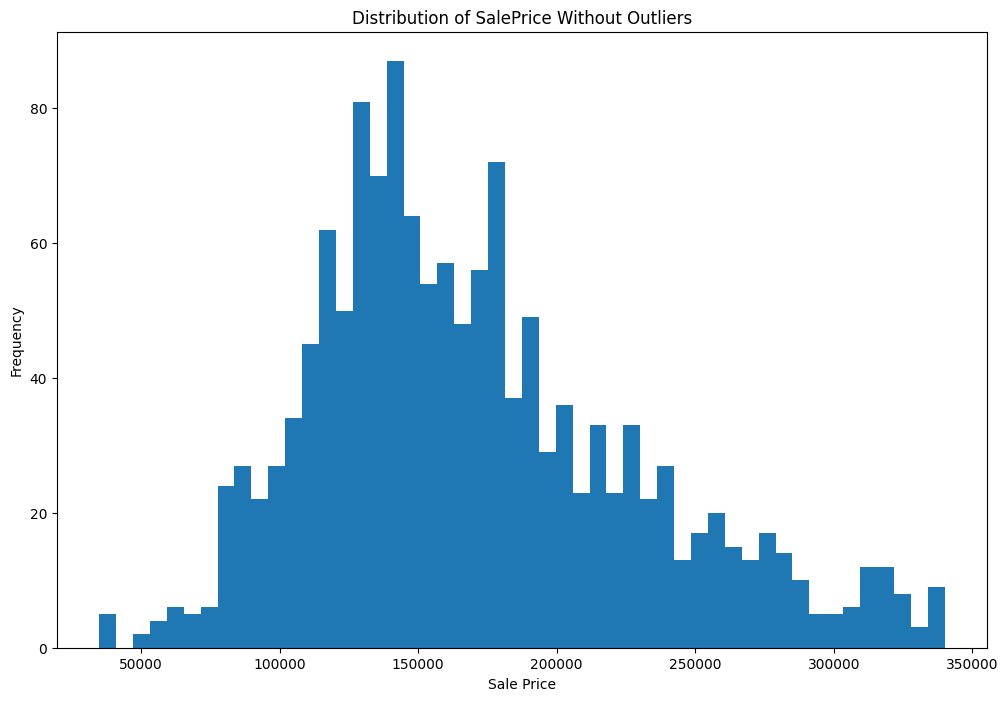

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.hist(df_no_outliers["SalePrice"], bins=50)
plt.title("Distribution of SalePrice Without Outliers")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()